<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/Evaluator_Optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> Този pattern: имаме Generator Node (много или няколко), Evaluator Node, имаме цикъл между тях

> Generator Node - подготвя някакво решение, output. Докато Evaluator Node имам за задача да критикува този output, да върне предложение как може да бъде подобрен

> Този процес ще бъде повтарян отново и отново докато не бъде изпълнено някакво условие



In [4]:
!pip install -q langgraph langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 1.5 MB/s eta 0:00:00


In [5]:
from IPython.display import Image
from google.colab import userdata
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.runnables import Runnable
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from pathlib import Path
from pydantic import BaseModel, Field, SecretStr
from typing import Annotated, List, TypedDict

openai_api_key = SecretStr(userdata.get('OPENAI_API_KEY'))

def display_graph(runnable: Runnable, output_png: Path) -> None:
    with output_png.open(mode="wb") as file:
        file.write(runnable.get_graph().draw_mermaid_png())

    display(Image(output_png, format="png"))

In [3]:
class GenerationState(TypedDict):
    topic: str
    code: str
    generation_messages: Annotated[List[BaseMessage], add_messages]
    quality: float | None
    feedback: str | None

In [6]:
GENERATOR_PROMPT = """
You are a helpful coding assistant.
Your task is to generate simple Python code.
"""

EVALUATOR_PROMPT = """
You are a pedantic code verifier.
Yiu task is to analyze Python code and point out problems, potential issues or quality improvements.
"""

class Evaluation(BaseModel):
    score: float = Field(ge= 0, le=10, description="Overall quality from 0 to 10.")
    feedback: str = Field(description ="Actionable feedback.")

generator_model = ChatOpenAI(model="gpt-5-mini",api_key= openai_api_key, reasoning_effort = "low")
evaluator_model = ChatOpenAI(model="gpt-5-nano",api_key= openai_api_key, reasoning_effort = "low").with_structured_output(Evaluation)


In [7]:
def generate(state: GenerationState):
    feedback = state.get('feedback')
    if feedback:
        task = HumanMessage(feedback)
    else:
        task = HumanMessage(state.get('topic'))

    print("Initiating \"generate\"...")
    response = generator_model.invoke(
        [
            SystemMessage(GENERATOR_PROMPT),
            *state.get('generation_messages'),
            task
        ]
    )

    print("Generated:")
    print(response.content)
    print()

    return { 'code': response.content, 'generation_messages': [task, response], 'quality': None, 'feedback': None }


def evaluate(state: GenerationState):
    print("Initiating \"generate\"...")

    response = evaluator_model.invoke(
        [
            SystemMessage(EVALUATOR_PROMPT),
            HumanMessage(state.get('code'))
        ]
    )

    print("Evaluation result:")
    print(response)
    print()

    return {'quality': response.score, 'feedback': response.feedback}


In [8]:
graph_builder = StateGraph(GenerationState)

graph_builder.add_node('generate',generate)
graph_builder.add_node('evaluate', evaluate)

graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", "evaluate")
graph_builder.add_conditional_edges('evaluate', lambda x: 'generate' if x.get('quality', 0) < 8 else END, ['generate', END] )

graph = graph_builder.compile()

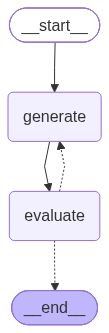

In [9]:
display_graph(graph, Path('/content/graph.png'))

In [10]:
final_state = graph.invoke(input={ "topic": "Write an algorithm to find the shortest path in a directed acyclic graph with weighted edges, even when some weights are negative." })

Initiating "generate"...
Generated:
Here's a simple, correct algorithm and Python implementation for finding shortest paths from a source in a directed acyclic graph (DAG) with weighted edges (including negative weights). The approach:

- Topologically sort the DAG.
- Initialize distances (distance[source] = 0, others = +inf).
- Relax edges in the topological order (each vertex relaxed once after all possible predecessors).

This works with negative weights because there are no cycles in a DAG, so no negative cycles can make the problem undefined.

Code:

```python
from collections import deque, defaultdict
import math

def topological_sort_kahn(graph):
    """
    Kahn's algorithm for topological sorting.
    graph: dict[node] -> list of (neighbor, weight)
    returns list of nodes in topological order
    """
    indeg = defaultdict(int)
    for u in graph:
        indeg[u] = indeg[u]  # ensure u in indeg
        for v, _w in graph[u]:
            indeg[v] += 1

    q = deque([node f

In [11]:
final_state

{'topic': 'Write an algorithm to find the shortest path in a directed acyclic graph with weighted edges, even when some weights are negative.',
 'code': 'Here\'s a simple, correct algorithm and Python implementation for finding shortest paths from a source in a directed acyclic graph (DAG) with weighted edges (including negative weights). The approach:\n\n- Topologically sort the DAG.\n- Initialize distances (distance[source] = 0, others = +inf).\n- Relax edges in the topological order (each vertex relaxed once after all possible predecessors).\n\nThis works with negative weights because there are no cycles in a DAG, so no negative cycles can make the problem undefined.\n\nCode:\n\n```python\nfrom collections import deque, defaultdict\nimport math\n\ndef topological_sort_kahn(graph):\n    """\n    Kahn\'s algorithm for topological sorting.\n    graph: dict[node] -> list of (neighbor, weight)\n    returns list of nodes in topological order\n    """\n    indeg = defaultdict(int)\n    for